# Meridian GeoX Demo

## Single cell design and analysis

This demo showcases an end-to-end single cell experiment design & analysis using
the library.

-   **Study Design**: Selecting the desired experiment type and using the Google
    design algorithms to generate a list of ranked, viable designs based on your
    specific marketing objectives. Finalize one optimal design based on your
    marketing needs and proceed with experiment implementation.
-   **Analysis & Inference**: Analyzing results using counterfactual modeling
    (e.g., time-based regression) and robust inference methods to evaluate
    statistical significance of incremental effect.

## Setup and Installation

Please follow the steps bellow in order to install and use the Meridian GeoX
library using Colab.

1.  **Connect to Hosted Runtime**

2.  **GitHub Authentication** Because the meridian_geox repository is currently
    private, you must provide a GitHub Personal Access Token (PAT) to clone the
    code and access the simulation datasets.

3.  **Generate a Token:** Visit https://github.com/settings/tokens and generate
    a new token with the repo scope enabled.

4.  **Security:** The setup cell below uses getpass.getpass() to ensure your
    token is handled as a secret and is not saved in the notebook's output or
    history.

In [ ]:
import getpass
import os

# Securely prompt for your GitHub Personal Access Token (PAT)
github_token = getpass.getpass("Enter your GitHub PAT: ")

# Clone the repo locally if it doesn't exist
if not os.path.exists("meridian-geox"):
  !git clone https://{github_token}@github.com/google/meridian-geox.git
else:
  print("Repository already exists. Skipping clone.")

# Install the library from the local folder
!pip install ./meridian-geox

In [2]:
import datetime
from pprint import pprint
import warnings
from IPython.display import display
import meridian_geox as geox
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    category=RuntimeWarning,
)

pd.set_option("display.max_columns", None)

meridian_geox_root = None

In [3]:
# If you prefer to save the design in Google Drive, run this cell.
import os
from google.colab import drive

drive_mount = '/content/drive'
drive.mount(drive_mount, force_remount=True)

# Optional: specify a subfolder to organize your runs
subfolder = ''  # @param {"type":"string", "placeholder": "e.g., my_geox_project"}

# Define the root path specifically for GeoX designs and reports
meridian_geox_root = f'{drive_mount}/MyDrive/{subfolder}'

# Create the directory if it doesn't exist
if not os.path.exists(meridian_geox_root):
  os.makedirs(meridian_geox_root)
  print(f'Created directory: {meridian_geox_root}')
else:
  print(f'Using directory: {meridian_geox_root}')

Mounted at /content/drive
Using directory: /content/drive/MyDrive/


## 1. Single cell design

A Single-Cell design tests exactly one marketing intervention (Treatment)
against a baseline control group (Control) within a single experiment.

### Load data

Generating a design requires at least 3N (where N is the pretest duration) of
pretest data. Please enter your data source link and column names.

-   **date**: `YYYY-MM-DD` string.
-   **location**: e.g., different market areas.
-   **conversion**: Recent conversion data is usually raw, unfiltered
    conversions or revenue data, typically from an advertiser's CRM. Conversion
    data should reflect a business-as-usual (BAU) situation.
-   **spend**: Spend data for campaigns included in the study. This is an
    optional column and is only required if the study/cell is a Go Dark or Heavy
    Up experiment.

In [4]:
# Specify the internal path to the design data CSV in the repository
single_cell_design_data_path = "/content/meridian-geox/meridian_geox/data/example_design_data_single_cell.csv"

# Load the data and the token provided in cell-1
single_cell_design_data = pd.read_csv(single_cell_design_data_path)

# Preview the first few rows to ensure it loaded correctly
single_cell_design_data.head()

,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


In [5]:
date_column_name = "date"  # @param {type:"string"}
location_column_name = "location"  # @param {type:"string"}
conversions_column_name = "conversions"  # @param {type:"string"}
spend_column_name = "spend"  # @param {type:"string"}

rename_mapping = {
    date_column_name: "date",
    location_column_name: "location",
    conversions_column_name: "conversions",
}

# Make spend column optional
if spend_column_name and spend_column_name in single_cell_design_data.columns:
  rename_mapping[spend_column_name] = "spend"

# Rename the columns in the dataframe to match the library's expected names
single_cell_design_data = single_cell_design_data.rename(columns=rename_mapping)

print("Columns mapped successfully!")
display(single_cell_design_data.head())

Columns mapped successfully!


,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


In [6]:
numeric_cols = ["conversions"]
if "spend" in single_cell_design_data.columns:
  numeric_cols.append("spend")

for colname in numeric_cols:
  single_cell_design_data[colname] = pd.to_numeric(
      single_cell_design_data[colname]
  )
single_cell_design_data["date"] = pd.to_datetime(
    single_cell_design_data["date"]
)
single_cell_design_data["location"] = single_cell_design_data[
    "location"
].astype(str)
single_cell_design_data.head()

,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


### Generate design

For detailed definitions of the experiment design input parameters, please refer
to the API references. Guidance for a couple of specific fields is provided
below.

**cost_per_incremental_conversion (CpIC)**: Equivalent to `1/target iROAS` if
revenue data is used. This is used to estimate budget requirements for a
holdback experiment (cell). The default is 1.0.

**Budget Constraints**: The budget constraint for the experiment design (per
cell). This could be a total budget amount or a budget percentage change. If the
budget percentage change is not specified for a go-dark or heavy-up cell, the
default value is 100%.

-   HOLDBACK: Enter the total spend budget limit (e.g.,
    `geox.Budget(budget=500000)`).
-   HEAVY_UP: Enter the budget change percentage (e.g.,
    `geox.Budget(budget_pct=0.5)` for a 50% spend increase). If not provided,
    the default value is 100%.
-   GO_DARK / GO_DIM: `geox.Budget(budget_pct=1.0)` for full go-dark (100% spend
    shutoff) or `geox.Budget(budget_pct=0.5)` for go-dim (50% spend reduction).
    If not provided, the default value is 100%.

**Exclusions (excluded_geos, excluded_dates)**: Pass the set of geos or dates to
exclude from the design. Remove the field or pass an empty set if there are no
geos or dates to exclude.

In [7]:
single_cell_design_config = geox.DesignConfig(
    experiment_duration=datetime.timedelta(days=30),
    experiment_types=geox.ExperimentType.HOLDBACK,
    methodology=geox.Methodology.TBR,
    geo_assignment_rule=geox.GeoAssignmentRule.STRATIFIED_SAMPLING,
    cost_per_incremental_conversion=1,
    cell_count=1,
    design_output_count=5,
)
single_cell_constraints = geox.Constraints(
    excluded_geos={"105"},
    budget_constraint=geox.Budget(budget=500000),
    max_conversions_percent=0.3,
)

Please indicate if you would like to automatically exclude geos with no response
and outlier dates during design.

If you set this to `False`, you will still see the detected outliers in the
results, allowing you to manually specify any exclusions using the `Constraints`
input above and regenerate your design.

In [8]:
exclude_geos_no_response = True  # @param {type:"boolean"}
exclude_outlier_dates_design = True  # @param {type:"boolean"}

design_data_quality_check_config = geox.QualityCheckConfig(
    exclude_geos_no_response=exclude_geos_no_response,
    exclude_outlier_dates=exclude_outlier_dates_design,
)

In [9]:
print("\nDesigning experiment...")
single_cell_design_set = geox.run_design(
    single_cell_design_data,
    single_cell_design_config,
    single_cell_constraints,
    design_data_quality_check_config,
)


Designing experiment...


### Check design results

List the design metrics for all generated designs. Please see the API references
for the definition of all design metrics.

In [10]:
single_cell_design_set.design_metrics

,design_id,cell,design_methodology,r2,mde,mde_abs,p_value,budget,treatment_conversions_pct,rank
0,c0ec6fa1-275f-42c4-bfe6-fb89bcc3c143,cell_1,STRATIFIED_SAMPLING-TBR,0.913179,0.013140,7085.925429,0.393857,7085.925429,30.072857,1
1,a6121894-2d71-437e-8195-03e58a2dcb59,cell_1,STRATIFIED_SAMPLING-TBR,0.916956,0.014234,7610.809836,0.919974,7610.809836,29.819897,2
2,7c6a59bb-624f-403e-a210-25a46dbf63bd,cell_1,STRATIFIED_SAMPLING-TBR,0.897182,0.014474,7610.808666,0.370634,7610.808666,29.325471,3
3,fd278ea6-e4a4-4668-93ed-7033d3fc552c,cell_1,STRATIFIED_SAMPLING-TBR,0.944819,0.014605,7873.250176,0.496679,7873.250176,30.063651,4
4,45e8d48a-ce2b-4b02-8e85-f305a245c221,cell_1,STRATIFIED_SAMPLING-TBR,0.915331,0.014617,7873.249345,0.169224,7873.249345,30.038615,5


Enter the selected design ID. Leave this empty to automatically select the
top-ranked design.

In [11]:
single_cell_selected_design_id = ""  # @param {type:"string"}

if not single_cell_selected_design_id.strip():
  single_cell_selected_design_id = single_cell_design_set.design_metrics[
      "design_id"
  ].iloc[0]
  print(
      "Automatically selected top ranked design ID:"
      f" {single_cell_selected_design_id}"
  )
else:
  print(f"Manually selected design ID: {single_cell_selected_design_id}")

Automatically selected top ranked design ID: c0ec6fa1-275f-42c4-bfe6-fb89bcc3c143


In [12]:
# Filter the design based on the selected ID
if single_cell_selected_design_id in single_cell_design_set.designs:
  selected_design = single_cell_design_set.designs[
      single_cell_selected_design_id
  ]
  print(f"Successfully selected design: {single_cell_selected_design_id}")
  pprint(selected_design)
else:
  print(
      "Error: Design ID not found. Please enter a valid ID from the metrics"
      " table above."
  )

Successfully selected design: c0ec6fa1-275f-42c4-bfe6-fb89bcc3c143
Design(designs={'cell_1': PerCellDesign(treatment_geos={'108',
                                                        '110',
                                                        '111',
                                                        '115',
                                                        '118',
                                                        '122',
                                                        '127',
                                                        '144',
                                                        '151',
                                                        '166',
                                                        '172',
                                                        '189',
                                                        '193',
                                                        '196',
                                                   

**Evaluating design feasibility (Design implied CpIC):**

Compare the `Implied CpIC` against your `Expected CpIC` to ensure the experiment
is adequately powered.

*   If Implied CpIC < Expected CpIC, your test is underpowered (unlikely to
    detect lift). You must increase budget or test duration.
*   If Implied CpIC ≥ Expected CpIC, your test is adequately powered.

For Holdback study, the design implied CpIC equals to your input CpIC.

In [13]:
selected_design = single_cell_design_set.designs[single_cell_selected_design_id]
print(
    "Design implied CpIC:"
    f" {selected_design.designs['cell_1'].design_implied_cpic}"
)

Design implied CpIC: 1.0


**Check the data quality and outlier detection results**

In [14]:
# If the output below shows empty sets, no outlier geos or dates were detected.
selected_design.quality_check_result

QualityCheckResult(quality_check_config=QualityCheckConfig(exclude_geos_no_response=True, exclude_outlier_dates=True), outlier_geos=set(), outlier_dates=set())

In [15]:
# Show all data quality check results.
if selected_design.quality_check_result is not None:
  design_quality_metrics = selected_design.quality_check_result.quality_metrics
  if design_quality_metrics.empty:
    print("No data quality issues identified.")
  else:
    display(design_quality_metrics)
else:
  print("No quality check result available.")

No data quality issues identified.


### Plot design

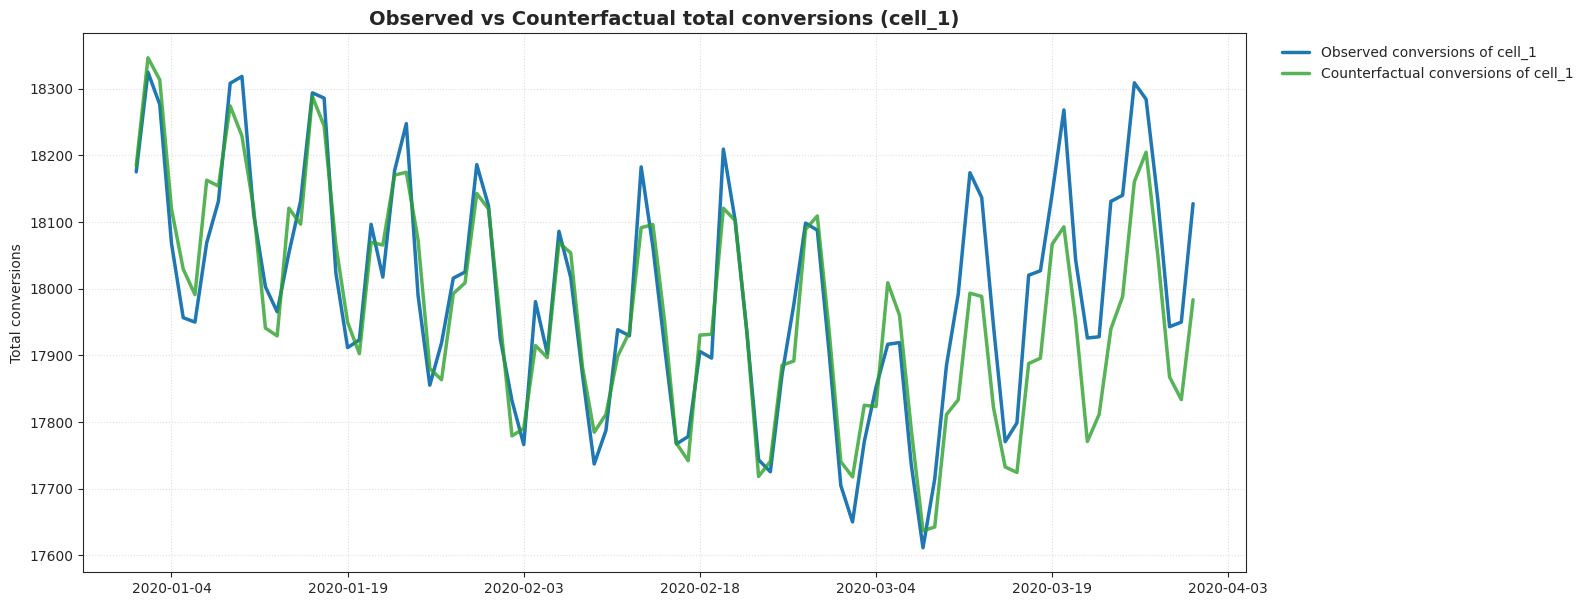

In [16]:
geox.plot_design(single_cell_design_set.designs[single_cell_selected_design_id])

### Save design

In [ ]:
single_cell_saved_design_json = single_cell_design_set.designs[
    single_cell_selected_design_id
].export_to_json()
single_cell_saved_design_json

In [18]:
# Write the JSON string to a file on Google Drive if mounted to Google Drive
if meridian_geox_root:
  single_cell_design_file_path = os.path.join(
      meridian_geox_root, "single_cell_design.json"
  )
  with open(single_cell_design_file_path, "w") as f:
    f.write(single_cell_saved_design_json)
  print(
      "Design successfully saved to Google Drive at:"
      f" {single_cell_design_file_path}"
  )
else:
  print("Google Drive not mounted. Design exists in session memory only.")

Design successfully saved to Google Drive at: /content/drive/MyDrive/single_cell_design.json


## 2. Single cell analysis

Post-experiment analysis (Run AFTER the experiment has completed).

### Load data and design

Dataset must include historical pretest data and test period data with optional
cooldown period data.

In [19]:
# Specify the path to the analysis CSV
single_cell_analysis_data_path = "/content/meridian-geox/meridian_geox/data/example_analysis_data_single_cell_holdback.csv"

# Load the data
single_cell_analysis_data = pd.read_csv(single_cell_analysis_data_path)
single_cell_analysis_data.head()

,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


In [20]:
date_column_name = "date"  # @param {type:"string"}
location_column_name = "location"  # @param {type:"string"}
conversions_column_name = "conversions"  # @param {type:"string"}
spend_column_name = "spend"  # @param {type:"string"}

rename_mapping = {
    date_column_name: "date",
    location_column_name: "location",
    conversions_column_name: "conversions",
}

# Make spend column optional
if spend_column_name and spend_column_name in single_cell_analysis_data.columns:
  rename_mapping[spend_column_name] = "spend"

# Rename the columns in the dataframe to match the library's expected names
single_cell_analysis_data = single_cell_analysis_data.rename(
    columns=rename_mapping
)

print("Columns mapped successfully!")
display(single_cell_analysis_data.head())

Columns mapped successfully!


,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


In [21]:
numeric_cols = ["conversions"]
if "spend" in single_cell_analysis_data.columns:
  numeric_cols.append("spend")

for colname in numeric_cols:
  single_cell_analysis_data[colname] = pd.to_numeric(
      single_cell_analysis_data[colname]
  )
single_cell_analysis_data["date"] = pd.to_datetime(
    single_cell_analysis_data["date"]
)
single_cell_analysis_data["location"] = single_cell_analysis_data[
    "location"
].astype(str)
single_cell_analysis_data.head()

,date,location,conversions,spend
0,2020-01-01,10,1217.186754,13.961282
1,2020-01-01,103,478.754850,5.360183
2,2020-01-01,105,1077.686355,11.070354
3,2020-01-01,108,347.516532,4.956830
4,2020-01-01,11,914.836202,10.872813


In [22]:
design_file_name = "single_cell_design.json"  # @param {type:"string"}

# Try to load the design from Google Drive, with a fallback to session memory.
single_cell_loaded_design = None

if meridian_geox_root:
  single_cell_design_file_path = os.path.join(
      meridian_geox_root, design_file_name
  )
  if os.path.exists(single_cell_design_file_path):
    with open(single_cell_design_file_path, "r") as f:
      single_cell_design_json_text = f.read()
    single_cell_loaded_design = geox.Design.load_from_json(
        single_cell_design_json_text
    )
    print(
        "Design successfully loaded from Google Drive:"
        f" {single_cell_design_file_path}"
    )
  else:
    print(
        f"Design file not found at {single_cell_design_file_path}. Will try to"
        " load from session memory."
    )

if single_cell_loaded_design is None:
  try:
    single_cell_loaded_design = geox.Design.load_from_json(
        single_cell_saved_design_json
    )
    print("Design successfully loaded from session memory.")
  except NameError:
    print(
        "Error: Design data not found on Drive or in memory. Please run the"
        " design step first."
    )

Design successfully loaded from Google Drive: /content/drive/MyDrive/single_cell_design.json


### Generate analysis

Please indicate if you would like to automatically remove outlier dates during
the pretest period.

If you set this to `False`, you will still see the detected outliers in the
results, allowing you to manually specify any exclusions using the
`AnalysisConfig` input and regenerate your analysis.

Note that all excluded geos during the design phase will be automatically
removed from the analysis phase.

In [23]:
exclude_outlier_dates_analysis = True  # @param {type:"boolean"}

analysis_data_quality_check_config = geox.QualityCheckConfig(
    exclude_outlier_dates=exclude_outlier_dates_analysis,
)

In [24]:
# Analyze experiment results
print("\nAnalyzing experiment results...")
single_cell_analysis_config = geox.AnalysisConfig(
    design=single_cell_loaded_design,
    analysis_start_date=pd.to_datetime("2020-04-01"),
    analysis_end_date=pd.to_datetime("2020-04-30"),
)
single_cell_analysis_result = geox.analyze(
    single_cell_analysis_data,
    single_cell_analysis_config,
    analysis_data_quality_check_config,
)


Analyzing experiment results...


### Check analysis result

Please check the API reference for the detailed analysis result definition.

iCPD is equivalent to iROAS if revenue data is used. It is populated if spend
data is available.

A geo experiment is considered statistically inconclusive when its confidence
interval includes zero.

In [25]:
print(f"Analysis result:")
pprint(single_cell_analysis_result.results)

Analysis result:
{'cell_1': AnalysisMetrics(lift=Estimate(point_estimate=31560.099609375,
                                         lower_bound=30311.10546875,
                                         upper_bound=32408.677734375,
                                         standard_deviation=718.8914184570312,
                                         p_value=0.0019960079807788134),
                           percent_lift=Estimate(point_estimate=0.05804109573364258,
                                                 lower_bound=0.05562400817871094,
                                                 upper_bound=0.05969846248626709,
                                                 standard_deviation=0.001395303988829255,
                                                 p_value=0.0019960079807788134),
                           icpd=Estimate(point_estimate=2.299304485321045,
                                         lower_bound=2.2083091735839844,
                                         upper_boun

In [26]:
# Show first 5 days of the time series data.
single_cell_analysis_result.results["cell_1"].cumulative_lift.head(5)

,lift,lower_bound,upper_bound
date,,,
2020-04-01,1150.123535,910.733398,1287.183105
2020-04-02,2228.712891,1809.801758,2453.713135
2020-04-03,3317.156982,2672.744873,3610.348633
2020-04-04,4318.226562,3569.225342,4604.825195
2020-04-05,5278.862305,4359.321777,5602.310059


In [27]:
if "spend" in single_cell_analysis_data.columns:
  display(single_cell_analysis_result.results["cell_1"].cumulative_icpd.head(5))
else:
  print(
      "Cumulative iCPD is not available because the 'spend' column was not"
      " provided."
  )

,icpd,lower_bound,upper_bound
date,,,
2020-04-01,2.469740,1.955681,2.764057
2020-04-02,2.421272,1.966168,2.665712
2020-04-03,2.409629,1.941519,2.622607
2020-04-04,2.357370,1.948481,2.513827
2020-04-05,2.299030,1.898555,2.439897


**Check the data quality and outlier detection results**

In [28]:
# If the output below shows empty sets, no outlier geos or dates were detected.
single_cell_analysis_result.quality_check_result

QualityCheckResult(quality_check_config=QualityCheckConfig(exclude_geos_no_response=True, exclude_outlier_dates=True), outlier_geos=set(), outlier_dates=set())

In [29]:
if single_cell_analysis_result.quality_check_result is not None:
  analysis_quality_metrics = (
      single_cell_analysis_result.quality_check_result.quality_metrics
  )
  if analysis_quality_metrics.empty:
    print("No data quality issues identified.")
  else:
    display(analysis_quality_metrics)
else:
  print("No quality check result available.")

No data quality issues identified.


### Plot analysis

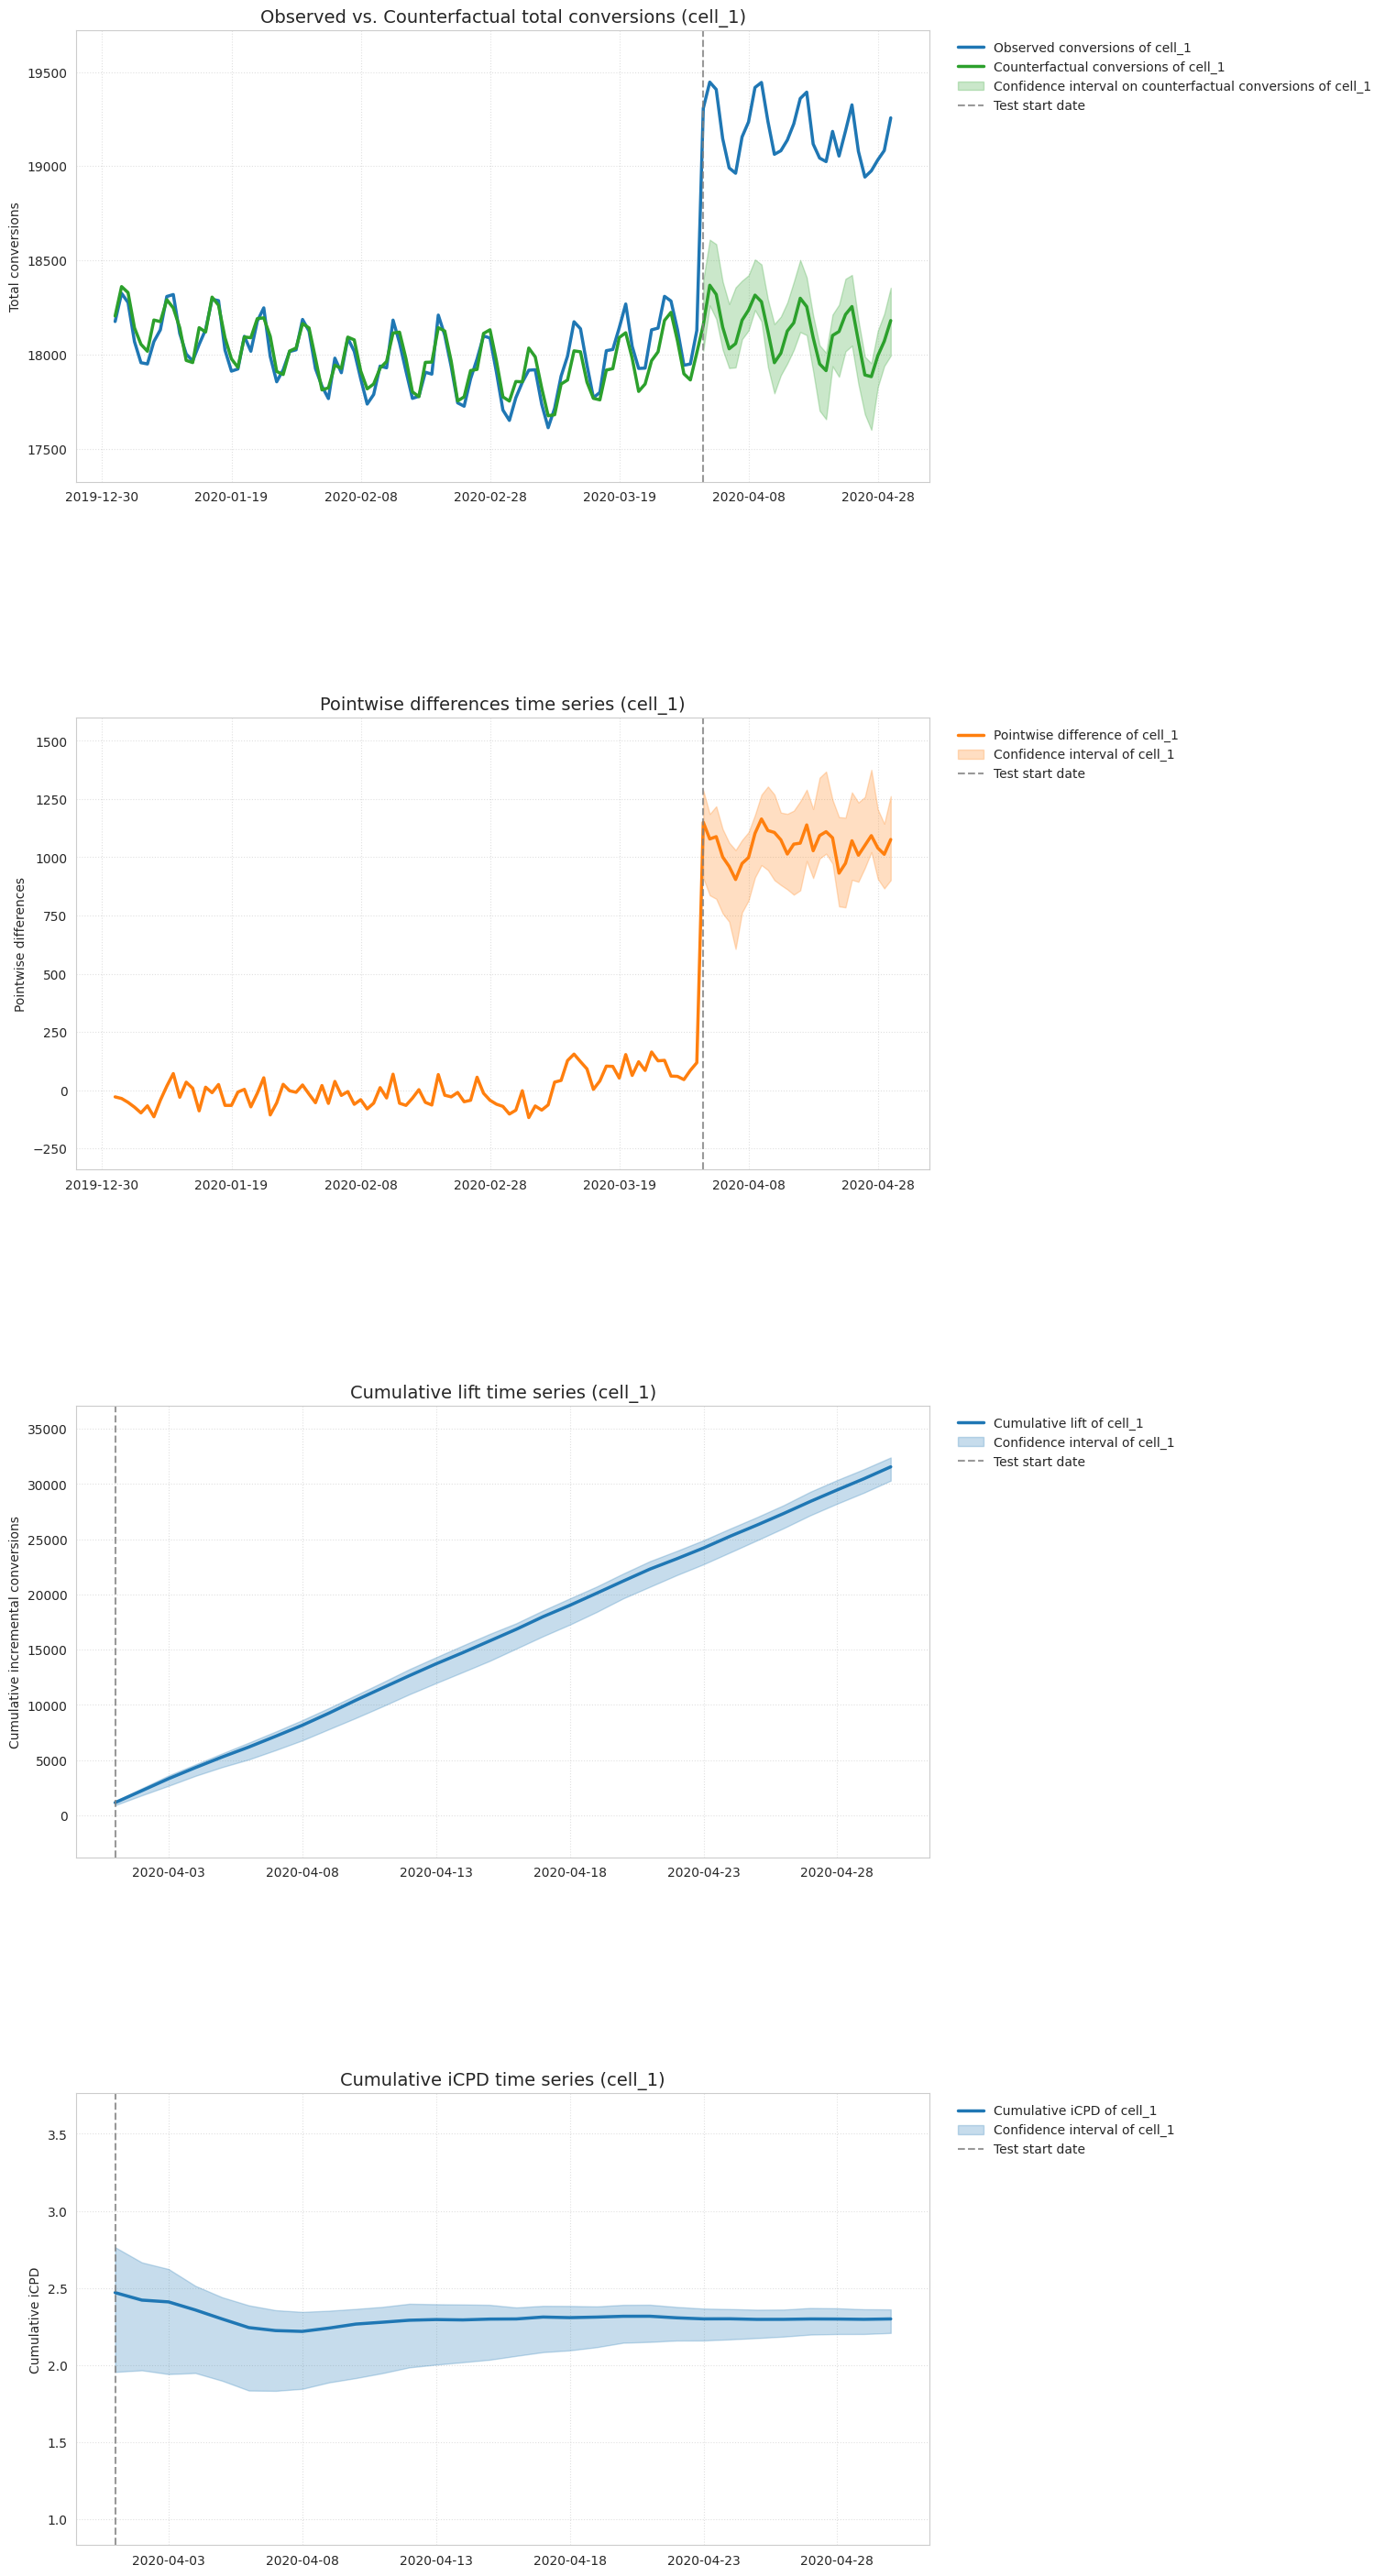

In [30]:
geox.plot_analysis(single_cell_analysis_result)

## 3. Compare designs

Single function call to test multiple `DesignConfig` setups (e.g., Random vs.
Stratified Sampling, or 14-day vs. 30-day duration) on the same dataset
side-by-side.

In [31]:
comparison_design_results = geox.compare_designs(
    single_cell_design_data,
    [
        (
            geox.DesignConfig(
                experiment_duration=datetime.timedelta(days=30),
                experiment_types=geox.ExperimentType.HOLDBACK,
                methodology=geox.Methodology.TBR,
                geo_assignment_rule=geox.GeoAssignmentRule.RANDOM,
            ),
            geox.Constraints(),
        ),
        (
            geox.DesignConfig(
                experiment_duration=datetime.timedelta(days=30),
                experiment_types=geox.ExperimentType.HOLDBACK,
                methodology=geox.Methodology.TBR,
                geo_assignment_rule=geox.GeoAssignmentRule.STRATIFIED_SAMPLING,
            ),
            geox.Constraints(),
        ),
    ],
)

In [32]:
# Best design (by MDE)
comparison_selected_design_id = next(iter(comparison_design_results.designs))
pprint(comparison_design_results.designs[comparison_selected_design_id])

Design(designs={'cell_1': PerCellDesign(treatment_geos={'11',
                                                        '110',
                                                        '118',
                                                        '120',
                                                        '127',
                                                        '128',
                                                        '133',
                                                        '138',
                                                        '152',
                                                        '166',
                                                        '168',
                                                        '169',
                                                        '180',
                                                        '188',
                                                        '190',
                                                        

In [33]:
comparison_design_results.design_metrics

,design_id,cell,design_methodology,r2,mde,mde_abs,p_value,budget,treatment_conversions_pct,rank
0,7700195d-7894-435a-9030-c892569932bf,cell_1,STRATIFIED_SAMPLING-TBR,0.898231,0.013740,7365.611917,0.102882,7365.611917,29.363000,1
1,b15b8393-86ca-4179-859a-9f476a9b4e09,cell_1,STRATIFIED_SAMPLING-TBR,0.907307,0.013830,7611.133275,0.189213,7611.133275,30.143827,2
2,8fbdf8b4-c41b-4e66-be42-d15278d1a5f9,cell_1,STRATIFIED_SAMPLING-TBR,0.924793,0.013885,7611.132883,0.387677,7611.132883,30.023558,3
3,c1a35854-c522-4b74-84af-eeddc467b461,cell_1,STRATIFIED_SAMPLING-TBR,0.902658,0.013893,7611.131517,0.168654,7611.131517,30.007393,4
4,50b65d4c-ea5b-4fbc-89d9-bc8b9c0b0f5d,cell_1,STRATIFIED_SAMPLING-TBR,0.893473,0.013914,7611.133096,0.344642,7611.133096,29.961924,5
5,aabad515-c22f-499d-b5a6-912e4bfb4432,cell_1,STRATIFIED_SAMPLING-TBR,0.906433,0.013979,7611.132762,0.470899,7611.132762,29.821772,6
6,2e83633b-c61c-483f-9163-3f4a843a9e07,cell_1,STRATIFIED_SAMPLING-TBR,0.919807,0.013984,7611.133260,0.842538,7611.133260,29.812235,7
7,97304a0f-7698-4b31-8dc5-a0e24942864a,cell_1,STRATIFIED_SAMPLING-TBR,0.927191,0.014404,7856.653952,0.449757,7856.653952,29.875190,8
8,49adc2ff-0ad2-4388-9933-61c2f70c72f7,cell_1,STRATIFIED_SAMPLING-TBR,0.894657,0.014420,7856.654093,0.367263,7856.654093,29.842799,9
9,2d534e84-1131-4b0f-acc5-aa58ee327c2e,cell_1,STRATIFIED_SAMPLING-TBR,0.895663,0.014442,7856.654611,0.312057,7856.654611,29.797912,10


## 4. Concatenate two designs

Combines pre-existing `DesignSet` objects into a single combined ranking table.

In [34]:
# Generate two single-cell designs
print("\nGenerating first single-cell design...")
design_config_1 = geox.DesignConfig(
    experiment_duration=datetime.timedelta(days=30),
    experiment_types=geox.ExperimentType.HOLDBACK,
    methodology=geox.Methodology.TBR,
    geo_assignment_rule=geox.GeoAssignmentRule.RANDOM,
    cell_count=1,
)
design_set_1 = geox.run_design(
    single_cell_design_data,
    design_config_1,
    constraints=geox.Constraints(),
)
print("First single-cell design generated.")
design_set_1.design_metrics


Generating first single-cell design...
First single-cell design generated.


,design_id,cell,design_methodology,r2,mde,mde_abs,p_value,budget,treatment_conversions_pct,rank
0,2007950b-e330-40af-ba49-a6ae697a424a,cell_1,RANDOM-TBR,0.907088,0.016222,8844.021336,0.397357,8844.021336,29.862267,1
1,c3e3ee4c-1c55-427e-afa6-7a3af84fa280,cell_1,RANDOM-TBR,0.889345,0.016245,8844.019753,0.375825,8844.019753,29.819729,2
2,67306db1-d4da-4779-b3e5-2cd1c550aa38,cell_1,RANDOM-TBR,0.894909,0.016264,8844.020442,0.668266,8844.020442,29.784047,3
3,75a6454d-ba3a-4639-b8b9-9e07d41bc79a,cell_1,RANDOM-TBR,0.899361,0.016269,8844.020390,0.191728,8844.020390,29.776098,4
4,27940de7-dfa3-4cfe-98be-bb662703974c,cell_1,RANDOM-TBR,0.895005,0.016280,8844.019216,0.309815,8844.019216,29.756174,5
5,8d84a04f-0598-4d29-80ab-87ebe3c6dd34,cell_1,RANDOM-TBR,0.905171,0.016300,8844.019580,0.751329,8844.019580,29.719798,6
6,ad1c9ede-0e24-4047-aa56-6f2b0d2567ee,cell_1,RANDOM-TBR,0.899662,0.016357,8844.018428,0.865474,8844.018428,29.615944,7
7,5cdcfef7-afed-44e3-9bb8-ae04c22e8074,cell_1,RANDOM-TBR,0.919025,0.016362,8844.019812,0.365670,8844.019812,29.607111,8
8,08954be1-32d1-42b3-a53f-f3b2e82ebc0a,cell_1,RANDOM-TBR,0.924565,0.016393,8844.020097,0.453785,8844.020097,29.549705,9
9,f04809e1-99c4-432b-b088-0d7203d6b117,cell_1,RANDOM-TBR,0.898441,0.016410,8844.020019,0.539502,8844.020019,29.520159,10


In [35]:
print("\nGenerating second single-cell design...")
design_config_2 = geox.DesignConfig(
    experiment_duration=datetime.timedelta(days=30),
    experiment_types=geox.ExperimentType.HOLDBACK,
    methodology=geox.Methodology.TBR,
    geo_assignment_rule=geox.GeoAssignmentRule.STRATIFIED_SAMPLING,
    cell_count=1,
)
design_set_2 = geox.run_design(
    single_cell_design_data, design_config_2, constraints=geox.Constraints()
)
print("Second single-cell design generated.")
design_set_2.design_metrics


Generating second single-cell design...
Second single-cell design generated.


,design_id,cell,design_methodology,r2,mde,mde_abs,p_value,budget,treatment_conversions_pct,rank
0,ed35a971-5180-492a-9329-786a82dd3458,cell_1,STRATIFIED_SAMPLING-TBR,0.898231,0.013740,7365.611917,0.102882,7365.611917,29.363000,1
1,c33dc98e-a1be-4c97-9d0d-aef2040bca44,cell_1,STRATIFIED_SAMPLING-TBR,0.907307,0.013830,7611.133275,0.189213,7611.133275,30.143827,2
2,1cc0d168-5ecb-4c0f-8d2a-a6e9b838db31,cell_1,STRATIFIED_SAMPLING-TBR,0.924793,0.013885,7611.132883,0.387677,7611.132883,30.023558,3
3,57ed7d7e-6612-4920-b929-9a031c332d4a,cell_1,STRATIFIED_SAMPLING-TBR,0.902658,0.013893,7611.131517,0.168654,7611.131517,30.007393,4
4,70e96d72-6f1d-4d00-855f-2a663277ffb2,cell_1,STRATIFIED_SAMPLING-TBR,0.893473,0.013914,7611.133096,0.344642,7611.133096,29.961924,5
5,1d5fe385-603d-488f-a97c-1fa54f71a8b1,cell_1,STRATIFIED_SAMPLING-TBR,0.906433,0.013979,7611.132762,0.470899,7611.132762,29.821772,6
6,b6ae4803-7e6b-49e4-8697-4ce1d307f830,cell_1,STRATIFIED_SAMPLING-TBR,0.919807,0.013984,7611.133260,0.842538,7611.133260,29.812235,7
7,6c8735cf-8a00-4e57-8317-885c472f506c,cell_1,STRATIFIED_SAMPLING-TBR,0.927191,0.014404,7856.653952,0.449757,7856.653952,29.875190,8
8,a79f2225-ebfc-4eac-88ba-8dcd7a66d425,cell_1,STRATIFIED_SAMPLING-TBR,0.894657,0.014420,7856.654093,0.367263,7856.654093,29.842799,9
9,a6220630-adea-4f88-a4c1-4b9644d01a0e,cell_1,STRATIFIED_SAMPLING-TBR,0.895663,0.014442,7856.654611,0.312057,7856.654611,29.797912,10


In [36]:
# Concatenate the two newly generated design sets
print("\nConcatenating the two single-cell design sets...")
combined_design_set = geox.concat_design_reports([design_set_1, design_set_2])

print("Combined design metrics (ranked by mde):")
combined_design_set.design_metrics


Concatenating the two single-cell design sets...
Combined design metrics (ranked by mde):


,design_id,cell,design_methodology,r2,mde,mde_abs,p_value,budget,treatment_conversions_pct,rank
0,ed35a971-5180-492a-9329-786a82dd3458,cell_1,STRATIFIED_SAMPLING-TBR,0.898231,0.013740,7365.611917,0.102882,7365.611917,29.363000,1
1,c33dc98e-a1be-4c97-9d0d-aef2040bca44,cell_1,STRATIFIED_SAMPLING-TBR,0.907307,0.013830,7611.133275,0.189213,7611.133275,30.143827,2
2,1cc0d168-5ecb-4c0f-8d2a-a6e9b838db31,cell_1,STRATIFIED_SAMPLING-TBR,0.924793,0.013885,7611.132883,0.387677,7611.132883,30.023558,3
3,57ed7d7e-6612-4920-b929-9a031c332d4a,cell_1,STRATIFIED_SAMPLING-TBR,0.902658,0.013893,7611.131517,0.168654,7611.131517,30.007393,4
4,70e96d72-6f1d-4d00-855f-2a663277ffb2,cell_1,STRATIFIED_SAMPLING-TBR,0.893473,0.013914,7611.133096,0.344642,7611.133096,29.961924,5
5,1d5fe385-603d-488f-a97c-1fa54f71a8b1,cell_1,STRATIFIED_SAMPLING-TBR,0.906433,0.013979,7611.132762,0.470899,7611.132762,29.821772,6
6,b6ae4803-7e6b-49e4-8697-4ce1d307f830,cell_1,STRATIFIED_SAMPLING-TBR,0.919807,0.013984,7611.133260,0.842538,7611.133260,29.812235,7
7,6c8735cf-8a00-4e57-8317-885c472f506c,cell_1,STRATIFIED_SAMPLING-TBR,0.927191,0.014404,7856.653952,0.449757,7856.653952,29.875190,8
8,a79f2225-ebfc-4eac-88ba-8dcd7a66d425,cell_1,STRATIFIED_SAMPLING-TBR,0.894657,0.014420,7856.654093,0.367263,7856.654093,29.842799,9
9,a6220630-adea-4f88-a4c1-4b9644d01a0e,cell_1,STRATIFIED_SAMPLING-TBR,0.895663,0.014442,7856.654611,0.312057,7856.654611,29.797912,10
